# NYC Taxi EDA → Interpretable Modeling

**Caleb Solomons, Mubeen Yacub**  


We start with EDA to answer our questions, then we build models that are interpretable enough to explain to stakeholders.

## What we’re doing
- Use EDA to make the patterns obvious (time-of-day, locations, payment types).
- Fit an interpretable regression model for `total_amount` (log-linear).
- Fit an interpretable classification model for tipping (`tip_amount > 0`).
- Use feature importance (permutation) to sanity-check what’s actually driving predictions.

## Update notes
- Fixed variable overwriting: regression and classification now use separate train/test splits (`*_reg`, `*_clf`).
- Fixed the end-of-notebook graphs:
  - Regression scatter uses the regression `y_test_reg` and `pred_log_reg`.
  - ROC curve uses the classifier `clf_model` and `predict_proba`.
- Permutation importance for regression uses an explicit regression scoring metric (`r2`).
- EDA histogram loop now plots each variable (the PDF version accidentally plotted `trip_distance` repeatedly).
- **Recommended for defense:** removed `total_amount` from the tipping classifier features to avoid target leakage (since `total_amount` includes tip). Can toggle it back on if your team explicitly wants that comparison.


## 0) Google Drive setup (Colab)
We're running this in Colab, so we mount Drive and set the dataset path.


In [1]:
# --- Google Drive Mount (Colab) ---
from google.colab import drive
drive.mount('/content/drive')

# Dataset path (CSV or Parquet)
DATA_PATH = "/content/drive/MyDrive/DSCI 591/2023_Yellow_Taxi_Trip_Data_20260112.csv"

# If a cell is "hanging" while loading the full CSV, set READ_NROWS to a smaller number
# (e.g., 5_000_000) to get results fast for EDA + modeling.
READ_NROWS = None  # None = load full file (may take a while)

# Taxi zone lookup path (used to convert PULocationID/DOLocationID into zone names)
ZONE_LOOKUP_PATH = "/content/drive/MyDrive/DSCI 591/taxi_zone_lookup.csv"


Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


## 1) Load the dataset
Load either Parquet or CSV. If the dataset is huge, we sample after loading/cleaning to keep runtime reasonable.


In [3]:
def load_taxi_data(path: str, read_nrows: int | None = None) -> pd.DataFrame:
    """Load taxi data.

    NOTE: The NYC taxi CSV can be very large. If loading feels like it 'hangs',
    set READ_NROWS in the cell above (e.g., 5_000_000) and/or restrict columns.
    """
    if path.lower().endswith(".parquet"):
        return pd.read_parquet(path)

    if path.lower().endswith(".csv"):
        # Only load columns we actually use downstream (speeds up IO + lowers RAM)
        usecols = [
            "VendorID","tpep_pickup_datetime","tpep_dropoff_datetime","passenger_count",
            "trip_distance","RatecodeID","store_and_fwd_flag","PULocationID","DOLocationID",
            "payment_type","fare_amount","extra","mta_tax","tip_amount","tolls_amount",
            "improvement_surcharge","total_amount","congestion_surcharge","airport_fee",
        ]
        # Some CSVs may omit a column; handle gracefully by loading all if needed
        try:
            return pd.read_csv(path, usecols=usecols, nrows=read_nrows)
        except ValueError:
            return pd.read_csv(path, nrows=read_nrows)

    raise ValueError("Unsupported file type. Use .parquet or .csv")

df_raw = load_taxi_data(DATA_PATH, read_nrows=READ_NROWS)
print("Raw shape:", df_raw.shape)
df_raw.head()


Raw shape: (38310226, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,01/01/2023 12:32:10 AM,01/01/2023 12:40:36 AM,1.0,0.97,1.0,N,161,141,2,9.3,1.0,0.5,0.0,0.0,1.0,14.3,2.5,0.00
1,2,01/01/2023 12:55:08 AM,01/01/2023 01:01:27 AM,1.0,1.1,1.0,N,43,237,1,7.9,1.0,0.5,4.0,0.0,1.0,16.9,2.5,0.00
2,2,01/01/2023 12:25:04 AM,01/01/2023 12:37:49 AM,1.0,2.51,1.0,N,48,238,1,14.9,1.0,0.5,15.0,0.0,1.0,34.9,2.5,0.00
3,1,01/01/2023 12:03:48 AM,01/01/2023 12:13:25 AM,0.0,1.9,1.0,N,138,7,1,12.1,7.25,0.5,0.0,0.0,1.0,20.85,0.0,1.25
4,2,01/01/2023 12:10:29 AM,01/01/2023 12:21:19 AM,1.0,1.43,1.0,N,107,79,1,11.4,1.0,0.5,3.28,0.0,1.0,19.68,2.5,0.00


## 2) Quick schema check
Before touching anything, look at columns + dtypes + missingness.


In [4]:
df_raw.info()
missing = df_raw.isna().mean().sort_values(ascending=False)
missing.head(25)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38310226 entries, 0 to 38310225
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          object 
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            object 
 11  extra                  object 
 12  mta_tax                float64
 13  tip_amount             object 
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           object 
 17  congestion_surcharge   float64
 18  airport_fee            float64
dtypes: float64(7), int64(4), object(8)
memory usage: 5.4+ GB


,0
store_and_fwd_flag,0.034178
RatecodeID,0.034178
passenger_count,0.034178
airport_fee,0.034178
congestion_surcharge,0.034178
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
DOLocationID,0.000000
PULocationID,0.000000


## 3) Clean + engineer features
- Convert numeric columns (some arrive as strings)
- Sample early for speed
- Parse datetimes
- Create duration + time features
- Create `tipped = 1` if `tip_amount > 0`
- Filter obvious garbage rows


In [5]:
df = df_raw.copy()

# Convert numeric columns first (so filters work)
to_num = ["trip_distance", "fare_amount", "extra", "tip_amount", "total_amount"]
for c in to_num:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Basic sanity filters that don't require datetimes yet
df = df.dropna(subset=["trip_distance", "total_amount", "tip_amount"])
df = df[(df["trip_distance"] > 0) & (df["trip_distance"] < 100)]
df = df[(df["total_amount"] > 0) & (df["total_amount"] < 500)]

# Sample EARLY (critical for speed)
EARLY_SAMPLE_N = 500_000  # try 200_000 if Colab is choking
if len(df) > EARLY_SAMPLE_N:
    df = df.sample(EARLY_SAMPLE_N, random_state=42).reset_index(drop=True)

# Parse datetimes (only on the sample)
pickup_col = "tpep_pickup_datetime" if "tpep_pickup_datetime" in df.columns else None
dropoff_col = "tpep_dropoff_datetime" if "tpep_dropoff_datetime" in df.columns else None
if pickup_col is None or dropoff_col is None:
    raise ValueError("Could not find pickup/dropoff datetime columns. Check your file schema.")

df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")

# Filter to 2023 immediately (cheap and helpful)
df = df[df[pickup_col].dt.year == 2023]

# Optional second sample after year filter
if len(df) > EARLY_SAMPLE_N:
    df = df.sample(EARLY_SAMPLE_N, random_state=42).reset_index(drop=True)

df[dropoff_col] = pd.to_datetime(df[dropoff_col], errors="coerce")

# Drop rows where datetimes failed
df = df.dropna(subset=[pickup_col, dropoff_col])

# Trip duration (minutes)
df["trip_duration_min"] = (df[dropoff_col] - df[pickup_col]).dt.total_seconds() / 60

# Time features
df["pickup_hour"] = df[pickup_col].dt.hour
df["pickup_dow"] = df[pickup_col].dt.dayofweek
df["is_weekend"] = (df["pickup_dow"] >= 5).astype(int)
df["is_night"] = df["pickup_hour"].isin([20,21,22,23,0,1,2,3,4,5]).astype(int)

# Tip target
df["tipped"] = (df["tip_amount"] > 0).astype(int)

# Conservative filters (tweakable)
df = df.dropna(subset=["trip_duration_min", "trip_distance", "total_amount"])
df = df[(df["trip_duration_min"] > 1) & (df["trip_duration_min"] < 300)]

print("Cleaned shape:", df.shape)
df[["trip_distance","trip_duration_min","pickup_hour","pickup_dow","total_amount","tip_amount","tipped"]].head()


Cleaned shape: (497963, 25)


,trip_distance,trip_duration_min,pickup_hour,pickup_dow,total_amount,tip_amount,tipped
0,3.20,36.433333,16,4,43.32,7.22,1
1,1.20,9.183333,7,3,17.64,2.94,1
2,3.49,17.566667,17,1,29.88,4.98,1
3,0.70,2.216667,16,1,13.90,2.30,1
4,1.21,8.416667,17,5,15.96,2.66,1


## 3b) Map taxi zone IDs → names
Convert `PULocationID` and `DOLocationID` to human-readable taxi zone names using the NYC TLC lookup file.

In [6]:
taxizone_lookup = pd.read_csv(ZONE_LOOKUP_PATH)
taxizone_lookup = taxizone_lookup[["LocationID", "Borough", "Zone", "service_zone"]]

id_to_zone = dict(zip(taxizone_lookup["LocationID"], taxizone_lookup["Zone"]))
id_to_borough = dict(zip(taxizone_lookup["LocationID"], taxizone_lookup["Borough"]))

# Add readable columns (safe even if some IDs are missing)
df["PU_zone"] = df["PULocationID"].map(id_to_zone)
df["PU_borough"] = df["PULocationID"].map(id_to_borough)
df["DO_zone"] = df["DOLocationID"].map(id_to_zone)
df["DO_borough"] = df["DOLocationID"].map(id_to_borough)

print("Zone mapping complete.")
df[["PULocationID","PU_borough","PU_zone","DOLocationID","DO_borough","DO_zone"]].head()


Zone mapping complete.


,PULocationID,PU_borough,PU_zone,DOLocationID,DO_borough,DO_zone
0,246,Manhattan,West Chelsea/Hudson Yards,231,Manhattan,TriBeCa/Civic Center
1,140,Manhattan,Lenox Hill East,236,Manhattan,Upper East Side North
2,162,Manhattan,Midtown East,158,Manhattan,Meatpacking/West Village West
3,186,Manhattan,Penn Station/Madison Sq West,90,Manhattan,Flatiron
4,144,Manhattan,Little Italy/NoLiTa,234,Manhattan,Union Sq


In [7]:
#access for the locatinID dict to give borough names and not simply ID numbers

import pandas as pd

vendorid = {1 : "Creative Mobile Technologies, LLC", 2 : "Curb Mobility, LLC", 6 : "Myle Technologies Inc", 7 : "Helix"}

ratecodeid = {1 : 'Standard rate', 2 : 'JFK', 3 : 'Newark', 4 : 'Nassau or Westchester', 5 : 'Negotiated fare', 6 : 'Group ride', 99 : 'Null/unknown'}

taxizonelookup = pd.read_csv('/content/drive/My Drive/DSCI 591/taxi_zone_lookup.csv')

tzl_features = ["LocationID", "Borough", "Zone service_zone"]

taxizonelookup

print(taxizonelookup)

     LocationID        Borough                     Zone service_zone
0             1            EWR           Newark Airport          EWR
1             2         Queens              Jamaica Bay    Boro Zone
2             3          Bronx  Allerton/Pelham Gardens    Boro Zone
3             4      Manhattan            Alphabet City  Yellow Zone
4             5  Staten Island            Arden Heights    Boro Zone
..          ...            ...                      ...          ...
260         261      Manhattan       World Trade Center  Yellow Zone
261         262      Manhattan           Yorkville East  Yellow Zone
262         263      Manhattan           Yorkville West  Yellow Zone
263         264        Unknown                      NaN          NaN
264         265            NaN           Outside of NYC          NaN

[265 rows x 4 columns]


## 4) Sampling for speed
A random sample still captures the core structure while keeping runtime reasonable.


In [8]:
SAMPLE_N = 300_000  # set to None to use full cleaned dataset
if SAMPLE_N is not None and len(df) > SAMPLE_N:
    df = df.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)
print("Working shape:", df.shape)


Working shape: (300000, 29)


## 5) EDA — baseline distributions
Distributions that drive everything: distance, duration, total, tip.
This also motivates using `log1p(total_amount)` later (right-skew).


In [9]:
eda_cols = ["trip_distance", "trip_duration_min", "total_amount", "tip_amount"]
df[eda_cols].describe(percentiles=[.5, .9, .95, .99])


,trip_distance,trip_duration_min,total_amount,tip_amount
count,300000.000000,300000.000000,300000.000000,300000.000000
mean,3.527653,16.548892,28.875861,3.583122
std,4.542264,13.343983,22.388287,3.988805
min,0.010000,1.016667,0.010000,0.000000
50%,1.820000,12.766667,21.000000,2.880000
90%,9.300000,32.683333,60.000000,7.550000
95%,15.700000,43.033333,82.690000,11.960000
99%,20.250000,66.883500,103.910000,17.510000
max,81.030000,297.683333,492.840000,200.000000


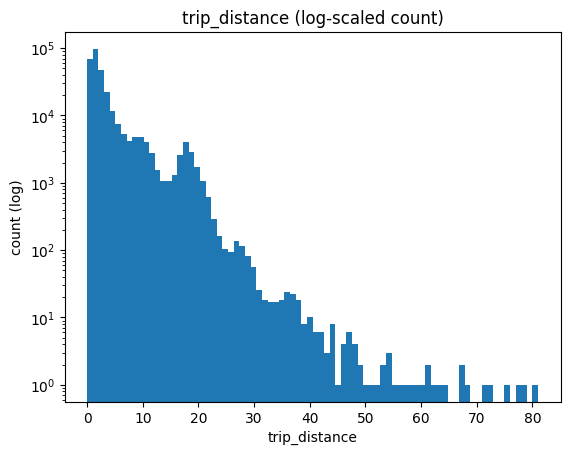

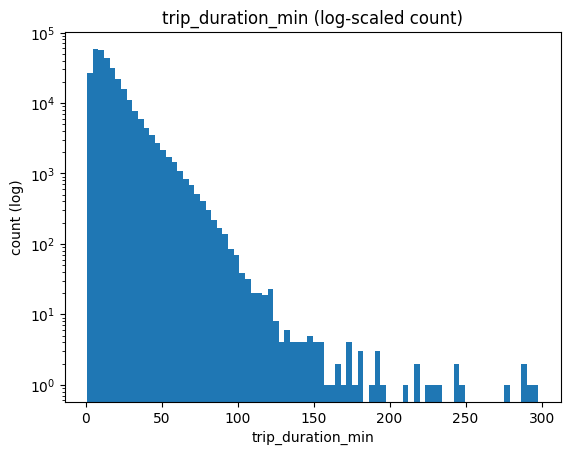

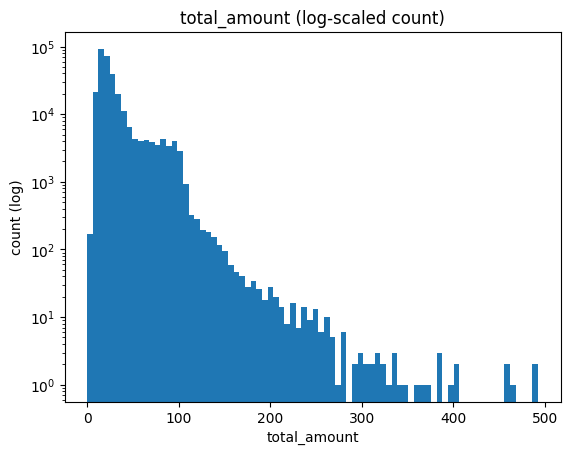

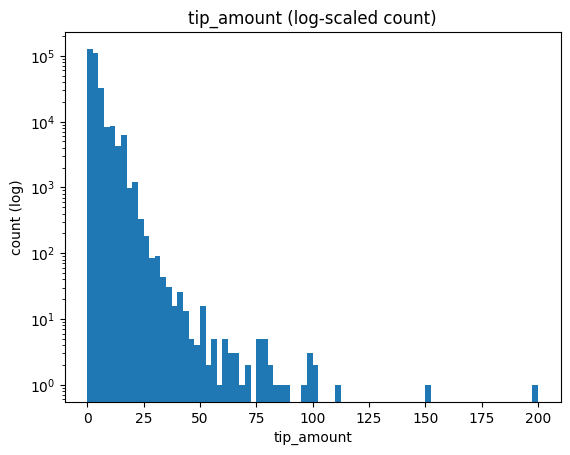

In [12]:
# Histograms (log-scaled count) — FIXED: plots each column instead of repeating trip_distance
for col in eda_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=80)
    plt.yscale("log")
    plt.title(f"{col} (log-scaled count)")
    plt.xlabel(col)  #revert to just col if issues occur
    plt.ylabel("count (log)")
    plt.show()


## 6) EDA — time of day (fare + tip behavior)
Answers: do fares and tips shift by time of day?
We look at mean/median total, mean tip, and tip rate.


In [13]:
hourly = df.groupby("pickup_hour").agg(
    trips=("pickup_hour", "size"),
    mean_total=("total_amount", "mean"),
    median_total=("total_amount", "median"),
    mean_tip=("tip_amount", "mean"),
    tip_rate=("tipped", "mean")
).reset_index()

hourly.head()


,pickup_hour,trips,mean_total,median_total,mean_tip,tip_rate
0,0,8480,29.257744,21.90,3.582428,0.789976
1,1,5586,26.576148,20.90,3.223240,0.786788
2,2,3715,25.470097,20.52,3.073203,0.781157
3,3,2475,26.910408,20.52,3.117261,0.740202
4,4,1613,33.358822,23.00,3.685121,0.687539


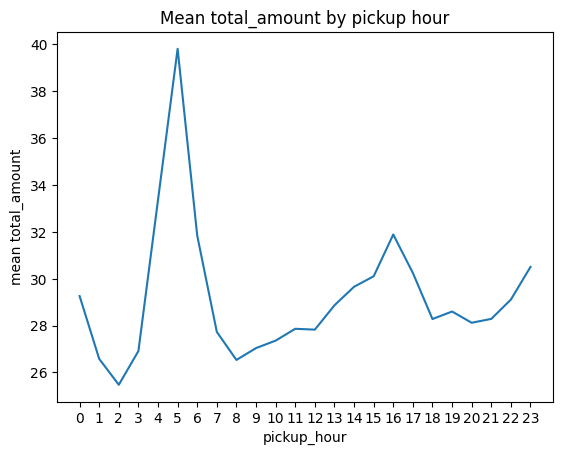

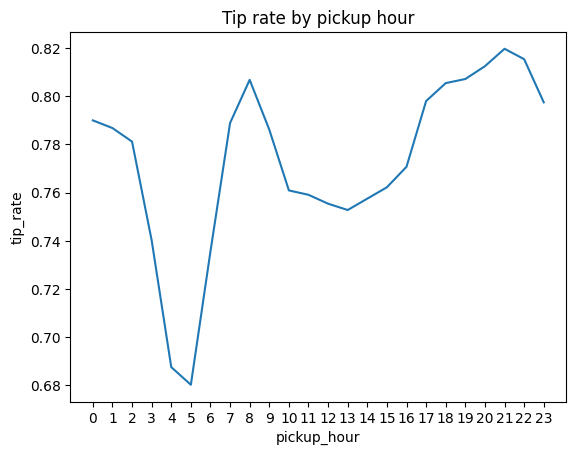

In [14]:
plt.figure()
plt.plot(hourly["pickup_hour"], hourly["mean_total"])
plt.title("Mean total_amount by pickup hour")
plt.xlabel("pickup_hour")
plt.ylabel("mean total_amount")
plt.xticks(range(0,24))
plt.show()

plt.figure()
plt.plot(hourly["pickup_hour"], hourly["tip_rate"])
plt.title("Tip rate by pickup hour")
plt.xlabel("pickup_hour")
plt.ylabel("tip_rate")
plt.xticks(range(0,24))
plt.show()


## 7) EDA — pickup/dropoff hotspots
Top-15 pickup and dropoff zones by trip count.


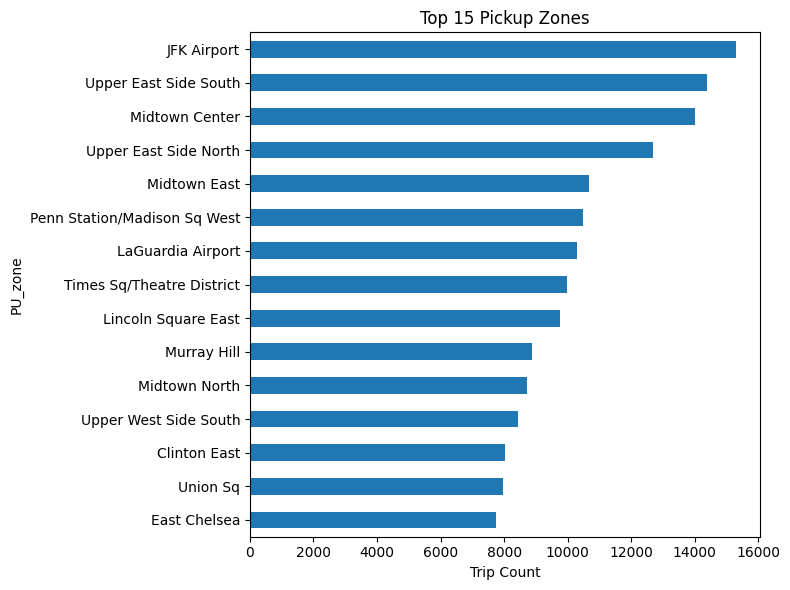

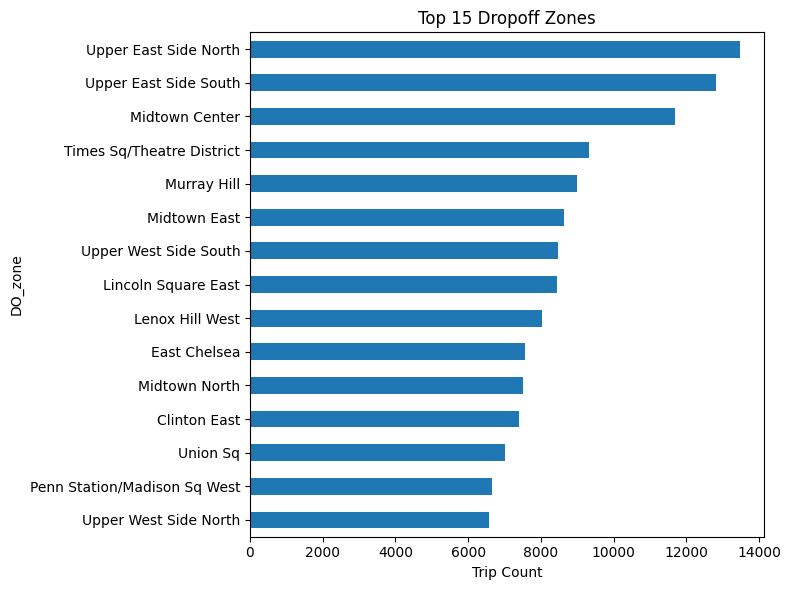

In [15]:
# Prefer human-readable zone labels if available; otherwise fall back to numeric IDs.
pu_label_col = "PU_zone" if "PU_zone" in df.columns else "PULocationID"
do_label_col = "DO_zone" if "DO_zone" in df.columns else "DOLocationID"

top_pu = df[pu_label_col].value_counts().head(15)
top_do = df[do_label_col].value_counts().head(15)

plt.figure(figsize=(8,6))
top_pu.sort_values().plot(kind="barh")
plt.title("Top 15 Pickup Locations" if pu_label_col=="PULocationID" else "Top 15 Pickup Zones")
plt.xlabel("Trip Count")
plt.ylabel(pu_label_col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
top_do.sort_values().plot(kind="barh")
plt.title("Top 15 Dropoff Locations" if do_label_col=="DOLocationID" else "Top 15 Dropoff Zones")
plt.xlabel("Trip Count")
plt.ylabel(do_label_col)
plt.tight_layout()
plt.show()


## 8) EDA — payment type vs total + tips
Does payment type relate to cost and tipping? (Also note confounding: card enables tipping more naturally than cash.)


In [16]:
if "payment_type" not in df.columns:
    raise ValueError("payment_type column not found.")

pay_summary = df.groupby("payment_type").agg(
    trips=("payment_type", "size"),
    mean_total=("total_amount", "mean"),
    median_total=("total_amount", "median"),
    tip_rate=("tipped", "mean"),
    mean_tip=("tip_amount", "mean")
).reset_index().sort_values("trips", ascending=False)

pay_summary


,payment_type,trips,mean_total,median_total,tip_rate,mean_tip
1,1,239449,29.600618,21.80,0.955256,4.367540
2,2,49495,25.174940,17.80,0.000040,0.000175
0,0,8215,31.277147,25.45,0.765307,3.538050
4,4,1810,26.253746,17.80,0.001105,0.024862
3,3,1031,23.690795,16.40,0.000970,0.014355


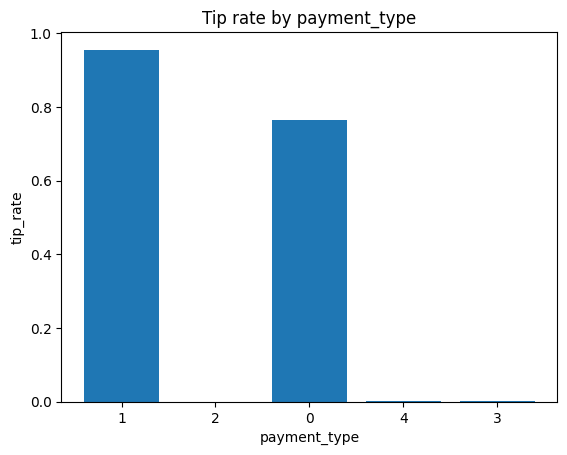

In [17]:
plt.figure()
plt.bar(pay_summary["payment_type"].astype(str), pay_summary["tip_rate"])
plt.title("Tip rate by payment_type")
plt.xlabel("payment_type")
plt.ylabel("tip_rate")
plt.show()


## 9) Modeling setup
Everything goes through a `ColumnTransformer` pipeline:
- numeric: median impute + standardize
- categorical: most-frequent impute + one-hot encode

This keeps preprocessing honest and reproducible.


In [18]:
def make_preprocess(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop"
    )


## 10) Regression — log-linear model for `total_amount`
Predict `log1p(total_amount)`.
Report MAE/RMSE in dollars (converted back), and R² in log-space.


In [19]:
# Target
y_reg = np.log1p(df["total_amount"])

# Feature candidates (kept defensive: we only use what exists)
reg_features = [
    "trip_distance", "trip_duration_min", "passenger_count",
    "pickup_hour", "pickup_dow", "is_weekend", "is_night",
    "PULocationID", "DOLocationID", "payment_type",
    "congestion_surcharge", "airport_fee", "tolls_amount",
    "RatecodeID", "store_and_fwd_flag", "VendorID"
]
reg_features = [c for c in reg_features if c in df.columns]
X_reg = df[reg_features].copy()

preprocess_reg = make_preprocess(X_reg)

reg_model = Pipeline(steps=[
    ("preprocess", preprocess_reg),
    ("model", LinearRegression())
])

# IMPORTANT: keep separate variables so we don't overwrite classification splits later
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model.fit(X_train_reg, y_train_reg)
pred_log_reg = reg_model.predict(X_test_reg)

# Convert back to dollars for MAE/RMSE
y_test_dollars = np.expm1(y_test_reg)
pred_dollars = np.expm1(pred_log_reg)

mae = mean_absolute_error(y_test_dollars, pred_dollars)
rmse = np.sqrt(mean_squared_error(y_test_dollars, pred_dollars))
r2 = r2_score(y_test_reg, pred_log_reg)

print("Regression (log1p total_amount)")
print(f"MAE (dollars): {mae:0.2f}")
print(f"RMSE (dollars): {rmse:0.2f}")
print(f"R^2 (log-space): {r2:0.4f}")


Regression (log1p total_amount)
MAE (dollars): 6.70
RMSE (dollars): 78.89
R^2 (log-space): 0.8524


## 11) Regression interpretation — coefficients
For numeric features, coefficients are on standardized scale.
Because target is `log1p(total_amount)`, coefficients roughly correspond to multiplicative shifts in total.


In [20]:
def extract_linear_coefficients(pipe: Pipeline, X: pd.DataFrame) -> pd.DataFrame:
    preprocess = pipe.named_steps["preprocess"]
    model = pipe.named_steps["model"]

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    feature_names = []
    feature_names.extend(num_cols)

    if len(cat_cols) > 0:
        ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
        ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
        feature_names.extend(ohe_names)

    coefs = model.coef_
    out = pd.DataFrame({"feature": feature_names, "coef": coefs})
    out["abs_coef"] = out["coef"].abs()
    return out.sort_values("abs_coef", ascending=False).reset_index(drop=True)

coef_df = extract_linear_coefficients(reg_model, X_reg)
coef_df.head(30)


,feature,coef,abs_coef
0,trip_duration_min,0.253434,0.253434
1,trip_distance,0.234078,0.234078
2,payment_type,-0.059363,0.059363
3,tolls_amount,0.040953,0.040953
4,RatecodeID,-0.026371,0.026371
5,airport_fee,0.025770,0.025770
6,is_night,0.020169,0.020169
7,pickup_hour,0.013119,0.013119
8,VendorID,0.010211,0.010211
9,is_weekend,-0.009061,0.009061


## 12) Classification — tipping likelihood (logistic regression)
Predict `tipped` (1 if `tip_amount > 0`).
We report accuracy and ROC AUC.

**Leakage note:** `total_amount` includes tip, so using it to predict `tipped` can inflate performance. For a defensible model, we exclude it here.


In [21]:
y_clf = df["tipped"].astype(int)

# Excluding total_amount by default to avoid leakage (total includes tip)
clf_features = [
    "trip_distance", "trip_duration_min", "passenger_count",
    "pickup_hour", "pickup_dow", "is_weekend", "is_night",
    "PULocationID", "DOLocationID", "payment_type",
    # "total_amount",  # optional; turn on only if you explicitly justify (and mention leakage risk)
    "congestion_surcharge", "airport_fee", "tolls_amount",
    "RatecodeID", "store_and_fwd_flag", "VendorID"
]
clf_features = [c for c in clf_features if c in df.columns]
X_clf = df[clf_features].copy()

preprocess_clf = make_preprocess(X_clf)

clf_model = Pipeline(steps=[
    ("preprocess", preprocess_clf),
    ("model", LogisticRegression(max_iter=2000))
])

# Separate split names to prevent overwriting regression variables
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf_model.fit(X_train_clf, y_train_clf)
proba_clf = clf_model.predict_proba(X_test_clf)[:, 1]
pred_clf = (proba_clf >= 0.5).astype(int)

acc = accuracy_score(y_test_clf, pred_clf)
auc = roc_auc_score(y_test_clf, proba_clf)

print("Classification (tipped)")
print(f"Accuracy: {acc:0.4f}")
print(f"ROC AUC : {auc:0.4f}")

print()
print(classification_report(y_test_clf, pred_clf))
cm = confusion_matrix(y_test_clf, pred_clf)
cm


Classification (tipped)
Accuracy: 0.9636
ROC AUC : 0.9175

              precision    recall  f1-score   support

           0       1.00      0.83      0.91     12995
           1       0.96      1.00      0.98     47005

    accuracy                           0.96     60000
   macro avg       0.98      0.92      0.94     60000
weighted avg       0.97      0.96      0.96     60000



array([[10814,  2181],
       [    2, 47003]])

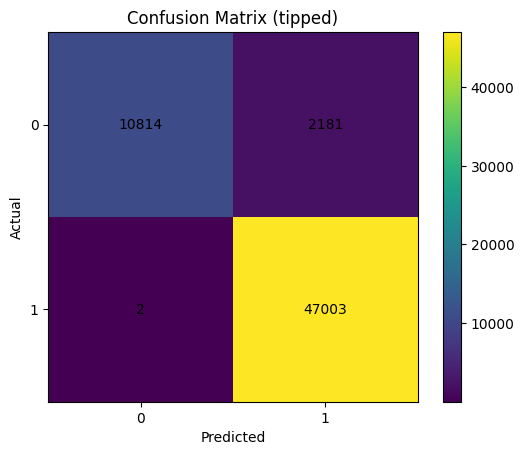

In [22]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (tipped)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1])
plt.yticks([0,1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 13) Logistic interpretation — odds ratios
Odds ratio = exp(beta).
We show top coefficients by magnitude so we’re not drowning in location dummies.


In [23]:
def extract_logistic_odds_ratios(pipe: Pipeline, X: pd.DataFrame) -> pd.DataFrame:
    preprocess = pipe.named_steps["preprocess"]
    model = pipe.named_steps["model"]

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    feature_names = []
    feature_names.extend(num_cols)

    if len(cat_cols) > 0:
        ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
        ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
        feature_names.extend(ohe_names)

    coefs = model.coef_[0]
    out = pd.DataFrame({"feature": feature_names, "coef": coefs})
    out["odds_ratio"] = np.exp(out["coef"])
    out["abs_coef"] = out["coef"].abs()
    return out.sort_values("abs_coef", ascending=False).reset_index(drop=True)

odds_df = extract_logistic_odds_ratios(clf_model, X_clf)
odds_df.head(30)


,feature,coef,odds_ratio,abs_coef
0,payment_type,-2.958514,0.051896,2.958514
1,RatecodeID,-1.193029,0.303301,1.193029
2,store_and_fwd_flag_N,0.644287,1.904629,0.644287
3,store_and_fwd_flag_Y,0.507615,1.661324,0.507615
4,congestion_surcharge,0.145559,1.156685,0.145559
5,trip_duration_min,-0.134796,0.873894,0.134796
6,DOLocationID,0.108141,1.114204,0.108141
7,pickup_hour,0.106333,1.112192,0.106333
8,is_night,-0.102012,0.903018,0.102012
9,airport_fee,0.095972,1.100728,0.095972


## 14) Permutation importance
If shuffling a feature column hurts performance, that feature mattered.
- Classification: AUC scoring
- Regression: R² scoring


In [24]:
# Classification permutation importance (AUC)
perm_clf = permutation_importance(
    clf_model, X_test_clf, y_test_clf,
    n_repeats=5, random_state=42, scoring="roc_auc"
)

imp_clf = pd.DataFrame({
    "feature": X_test_clf.columns,
    "importance_mean": perm_clf.importances_mean,
    "importance_std": perm_clf.importances_std
}).sort_values("importance_mean", ascending=False)

imp_clf.head(20)


,feature,importance_mean,importance_std
9,payment_type,0.373807,0.001201
13,RatecodeID,0.005658,0.000259
10,congestion_surcharge,0.004424,0.000373
1,trip_duration_min,0.002647,0.000228
8,DOLocationID,0.001763,0.000468
6,is_night,0.001425,0.000181
5,is_weekend,0.001223,0.000098
3,pickup_hour,0.001199,0.000317
7,PULocationID,0.000935,0.000207
4,pickup_dow,0.000859,0.000114


In [25]:
# Regression permutation importance (R²)
perm_reg = permutation_importance(
    reg_model, X_test_reg, y_test_reg,
    n_repeats=5, random_state=42, scoring="r2"
)

imp_reg = pd.DataFrame({
    "feature": X_test_reg.columns,
    "importance_mean": perm_reg.importances_mean,
    "importance_std": perm_reg.importances_std
}).sort_values("importance_mean", ascending=False)

imp_reg.head(20)


,feature,importance_mean,importance_std
1,trip_duration_min,4.266151e-01,2.265023e-03
0,trip_distance,3.625806e-01,3.607667e-03
9,payment_type,2.417863e-02,2.157579e-04
12,tolls_amount,1.049857e-02,2.696455e-04
13,RatecodeID,4.554805e-03,1.774755e-04
11,airport_fee,4.276789e-03,1.790270e-04
6,is_night,2.764236e-03,9.029809e-05
3,pickup_hour,1.180151e-03,4.302047e-05
15,VendorID,6.355432e-04,5.719777e-05
5,is_weekend,5.130194e-04,4.464468e-05


## 15) Extra visuals (fixed)
These were the cells that broke in the PDF.
- Correlation heatmap
- Regression: predicted vs actual
- ROC curve for tipping model


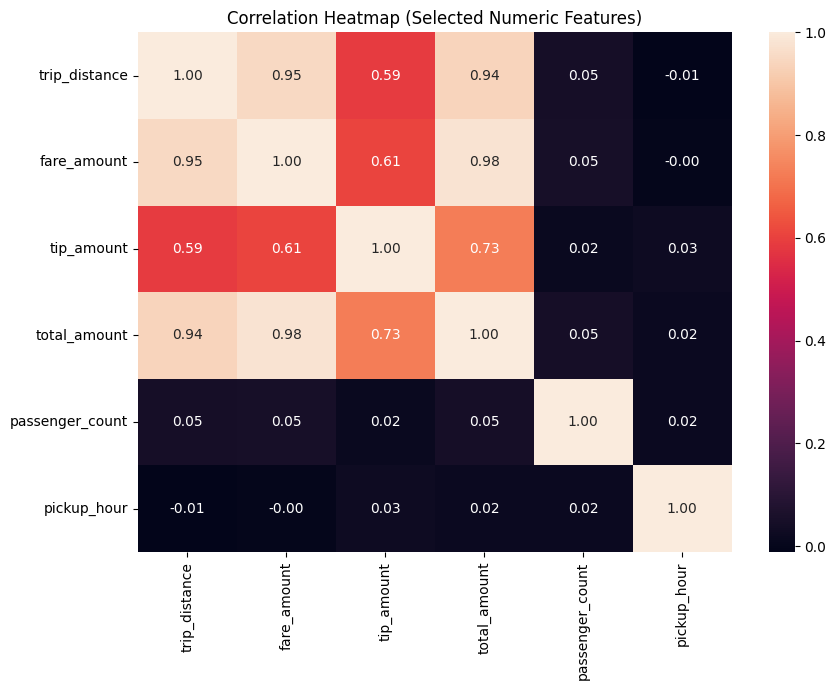

In [26]:
# Correlation heatmap (selected numeric features)
import seaborn as sns

cols = ["trip_distance","fare_amount","tip_amount","total_amount","passenger_count","pickup_hour"]
cols = [c for c in cols if c in df.columns]
Xcorr = df[cols].copy()

corr = Xcorr.corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Selected Numeric Features)")
plt.tight_layout()
plt.show()


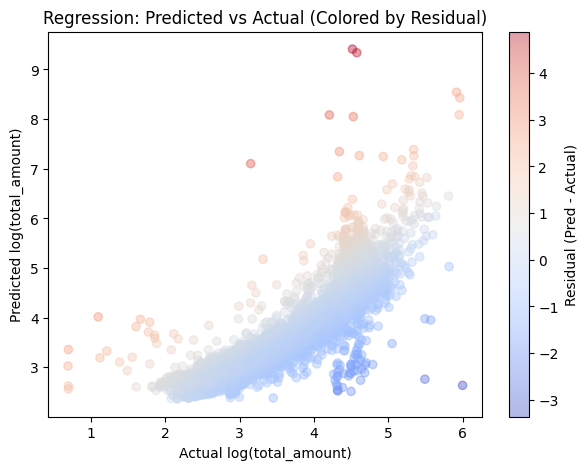

'Positive Residual (Red)\n\nPredicted > Actual\n\nThe model overpredicted the fare.\n\nExample:\n\nActual log(total) = 3.0\n\nPredicted log(total) = 4.0\n\nResidual = +1.0\n\nModel thinks the ride cost more than it really did.\n\nNegative Residual (Blue)\n\nPredicted < Actual\n\nThe model underpredicted the fare.\n\nActual = 5.0\n\nPredicted = 3.5\n\nResidual = -1.5\n\nModel thinks the ride cost less than it really did.\n\nNear Zero (White)\n\nPrediction ≈ Actual\n\nModel is accurate there.\n\n***Mid-range fares cluster near white → model performs well there.\n\nSome higher fares show red → model overpredicting.\n\nSome high fares show blue → model underpredicting.\n\nThis suggests:\n\nThe model performs best in the dense middle of the distribution and struggles with extreme values.***'

In [27]:
residuals = pred_log_reg - y_test_reg

plt.figure(figsize=(7,5))
plt.scatter(y_test_reg, pred_log_reg,
            c=residuals, cmap="coolwarm", alpha=0.4)

plt.colorbar(label="Residual (Pred - Actual)")
plt.xlabel("Actual log(total_amount)")
plt.ylabel("Predicted log(total_amount)")
plt.title("Regression: Predicted vs Actual (Colored by Residual)")
plt.show()

'''Positive Residual (Red)

Predicted > Actual

The model overpredicted the fare.

Example:

Actual log(total) = 3.0

Predicted log(total) = 4.0

Residual = +1.0

Model thinks the ride cost more than it really did.

Negative Residual (Blue)

Predicted < Actual

The model underpredicted the fare.

Actual = 5.0

Predicted = 3.5

Residual = -1.5

Model thinks the ride cost less than it really did.

Near Zero (White)

Prediction ≈ Actual

Model is accurate there.

***Mid-range fares cluster near white → model performs well there.

Some higher fares show red → model overpredicting.

Some high fares show blue → model underpredicting.

This suggests:

The model performs best in the dense middle of the distribution and struggles with extreme values.***'''

AUC: 0.9174567669178317


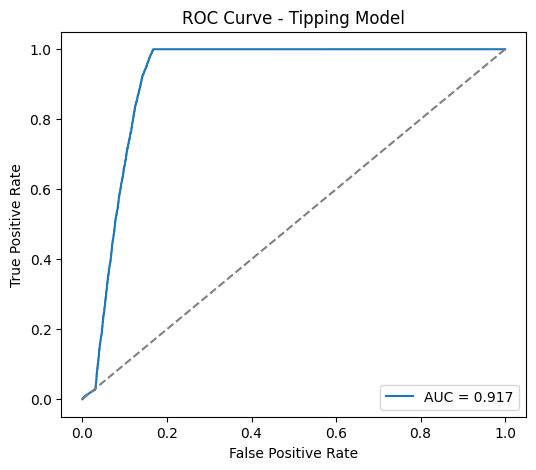

In [28]:
# ROC Curve - Tipping Model — FIXED: uses clf_model.predict_proba
fpr, tpr, _ = roc_curve(y_test_clf, proba_clf)


print("AUC:", roc_auc_score(y_test_clf, proba_clf))

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tipping Model")
plt.legend()
plt.show()


## 17) Additional visuals for the final presentation

These are **high-signal** visuals that are easy to explain:

- **Tip-rate heatmap (Day of Week × Hour)**: shows commute vs night-life behavior.
- **Borough summary**: trip volume, average total, and tip rate by pickup borough.
- **Trip behavior clustering (KMeans)**: segments trips into interpretable groups (short hops vs longer premium trips, etc.).
- **Regression residual plot**: checks where the regression is biased.


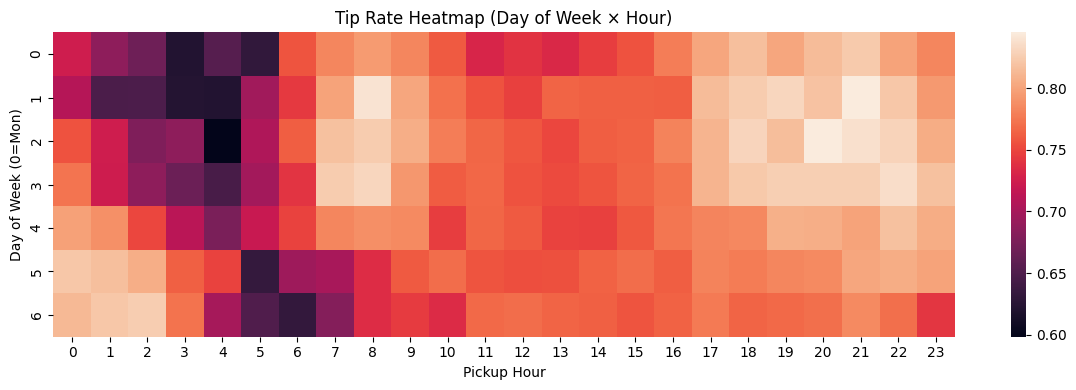

In [29]:
# Tip-rate heatmap: Day of Week × Hour
import seaborn as sns

pivot_tip = df.pivot_table(
    values="tipped",
    index="pickup_dow",
    columns="pickup_hour",
    aggfunc="mean"
)

plt.figure(figsize=(12, 4))
sns.heatmap(pivot_tip, annot=False)
plt.title("Tip Rate Heatmap (Day of Week × Hour)")
plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week (0=Mon)")
plt.tight_layout()
plt.show()


,trips,mean_total,tip_rate
PU_borough,,,
Manhattan,266375,24.014979,0.794481
Queens,28596,73.360100,0.712232
Unknown,2536,31.317137,0.780363
Brooklyn,1977,34.060830,0.499747
Bronx,410,34.361878,0.085366
Staten Island,7,74.837143,0.000000
EWR,4,115.547500,0.500000


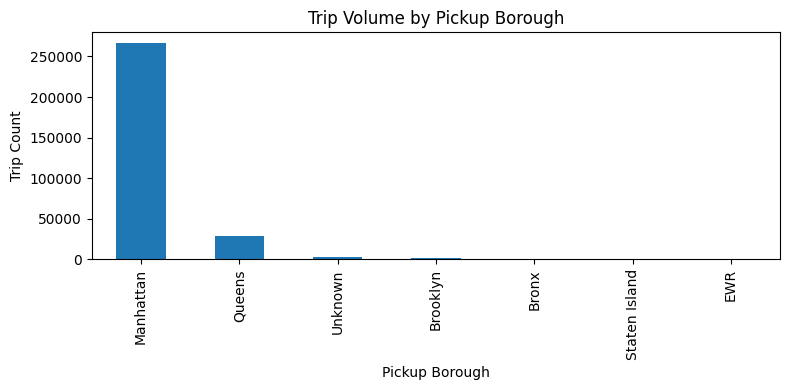

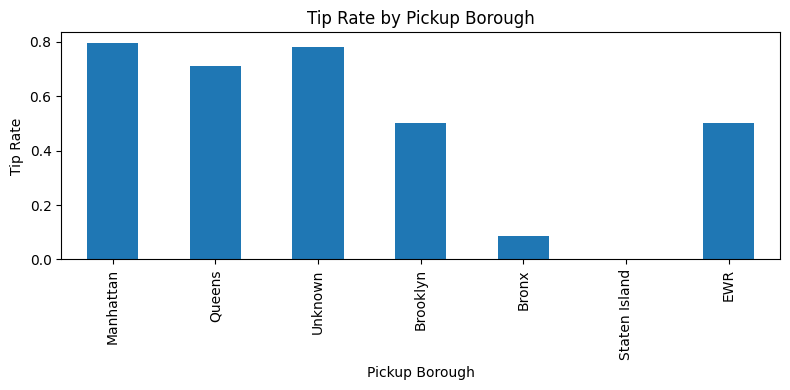

In [30]:
# Borough-level summary (requires zone mapping cell)
if "PU_borough" in df.columns:
    borough_summary = df.groupby("PU_borough").agg(
        trips=("PU_borough","size"),
        mean_total=("total_amount","mean"),
        tip_rate=("tipped","mean")
    ).sort_values("trips", ascending=False)

    display(borough_summary)

    plt.figure(figsize=(8,4))
    borough_summary["trips"].plot(kind="bar")
    plt.title("Trip Volume by Pickup Borough")
    plt.xlabel("Pickup Borough")
    plt.ylabel("Trip Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    borough_summary["tip_rate"].plot(kind="bar")
    plt.title("Tip Rate by Pickup Borough")
    plt.xlabel("Pickup Borough")
    plt.ylabel("Tip Rate")
    plt.tight_layout()
    plt.show()
else:
    print("PU_borough not found. Run the zone mapping cell first.")


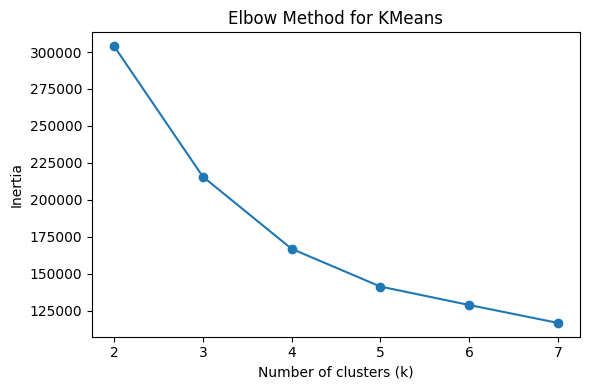

,trip_distance,trip_duration_min,total_amount,pickup_hour,tipped
cluster,,,,,
0,2.18,13.54,23.73,18.30,1.00
1,14.60,43.95,83.01,14.24,0.78
2,2.29,13.44,19.81,13.88,0.00
3,2.13,12.49,21.82,8.35,1.00


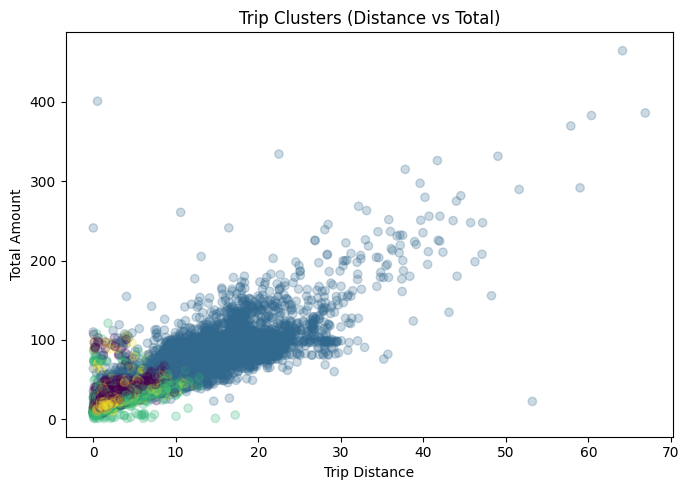

In [31]:
# Trip behavior clustering (KMeans)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = ["trip_distance", "trip_duration_min", "total_amount", "pickup_hour", "tipped"]
cluster_df = df[cluster_features].dropna().copy()

# Use a smaller sample for clustering to keep it fast (presentation-friendly)
CLUSTER_SAMPLE_N = 100_000
if len(cluster_df) > CLUSTER_SAMPLE_N:
    cluster_df = cluster_df.sample(CLUSTER_SAMPLE_N, random_state=42).reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

# Elbow method (quick)
inertia = []
K_RANGE = range(2, 8)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(K_RANGE), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.tight_layout()
plt.show()

# Choose k=4 as a reasonable default for interpretability
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

# Cluster profiles (means)
cluster_profile = cluster_df.groupby("cluster").mean(numeric_only=True).round(2)
display(cluster_profile)

# Visualize: distance vs total, colored by cluster
plt.figure(figsize=(7,5))
plt.scatter(cluster_df["trip_distance"], cluster_df["total_amount"], c=cluster_df["cluster"], alpha=0.25)
plt.xlabel("Trip Distance")
plt.ylabel("Total Amount")
plt.title("Trip Clusters (Distance vs Total)")
plt.tight_layout()
plt.show()


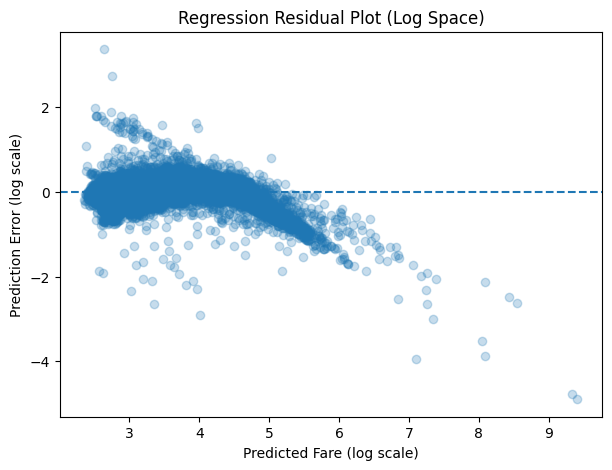

In [32]:
log_residuals = y_test_reg - pred_log_reg

plt.figure(figsize=(7,5))
plt.scatter(pred_log_reg, log_residuals, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare (log scale)")
plt.ylabel("Prediction Error (log scale)")
plt.title("Regression Residual Plot (Log Space)")
plt.show()

In [33]:
print("Max log prediction:", pred_log_reg.max())
print("Min log prediction:", pred_log_reg.min())
print("Max predicted dollars:", pred_dollars.max())
print("Max actual dollars:", y_test_dollars.max())

Max log prediction: 9.409574602357008
Min log prediction: 2.3563814849867524
Max predicted dollars: 12203.678030609879
Max actual dollars: 401.0


## 16) Wrap-up: what we can say to a stakeholder
- **Time-of-day:** quantify how totals shift (regression) and how odds of tipping shift (logistic).
- **Locations:** identify pickup/dropoff zones associated with higher totals or tipping likelihood.
- **Payment type:** show strong association with tipping (and note confounding).
- **Distance & duration:** remain dominant drivers of total cost, which is reassuring.

If we want an additional “strong model” comparison, add boosted trees + SHAP — but only if it adds insight rather than just flash.
